In [ ]:
import pandas as pd
import seaborn as sns

# Dosya yolunu Colab'deki konuma göre güncelliyoruz
file_path = '/content/dataset.csv'

try:
    # Veriyi okuyoruz
    df = pd.read_csv(file_path)
    print("Veri seti başarıyla yüklendi.")
    print(f"Toplam {df.shape[0]} satır ve {df.shape[1]} sütun bulundu.")
    print("\nVerinin İlk 5 Satırı:")
    print(df.head())

except FileNotFoundError:
    print(f"HATA: '{file_path}' adında bir dosya bulunamadı. Lütfen sol taraftaki panelde dosyanın adının tam olarak 'dataset.csv' olduğundan emin olun.")

except Exception as e:
    # Diğer olası hataları yakalamak için
    print(f"Bilinmeyen bir hata oluştu: {e}")

Veri seti başarıyla yüklendi.
Toplam 78792 satır ve 21 sütun bulundu.

Verinin İlk 5 Satırı:
   Year LocationAbbr      LocationDesc GeographicLevel DataSource  \
0  2020           AK            Denali          County       NVSS   
1  2020           CA        California           State       NVSS   
2  2020           CO       Park County          County       NVSS   
3  2020           FL     Walton County          County       NVSS   
4  2020           GA  Whitfield County          County       NVSS   

                     Class                    Topic  Data_Value  \
0  Cardiovascular Diseases  Heart Disease Mortality       348.8   
1  Cardiovascular Diseases  Heart Disease Mortality       230.1   
2  Cardiovascular Diseases  Heart Disease Mortality       135.9   
3  Cardiovascular Diseases  Heart Disease Mortality       126.5   
4  Cardiovascular Diseases  Heart Disease Mortality       155.1   

          Data_Value_Unit                                    Data_Value_Type  \
0  per 10

In [ ]:
#  1. VERİ FİLTRELEME
# Sadece 'County' (ilçe) düzeyindeki verileri tut
df_clean = df[df['GeographicLevel'] == 'County'].copy()
print(f"Sadece ilçe (County) verisi seçildi. Satır sayısı: {df_clean.shape[0]}")

# Analiz için gereksiz veya tekdüze olan sütunları belirleme
cols_to_drop = [
    'Year', 'DataSource', 'Class', 'Topic', 'GeographicLevel',
    'Data_Value_Type', 'Data_Value_Unit', 'Data_Value_Footnote_Symbol',
    'Data_Value_Footnote', 'StratificationCategory1', 'StratificationCategory2',
    'TopicID', 'ClassID', 'TopicType',
    'LocationDesc'
]
#  2. SÜTUNLARI YENİDEN ADLANDIRMA
# Sütunları daha anlaşılır isimlerle yeniden adlandırma
existing_cols_to_drop = [col for col in cols_to_drop if col in df_clean.columns]
df_clean = df_clean.drop(columns=existing_cols_to_drop)

df_clean = df_clean.rename(columns={
    'LocationAbbr': 'State',
    'LocationID': 'FIPS',
    'Data_Value': 'Mortality_Rate',
    'Stratification1': 'Gender',
    'Stratification2': 'Race_Ethnicity'
})

print("Gereksiz sütunlar atıldı ve sütunlar yeniden adlandırıldı.")
# Temizlenmiş ve yeniden adlandırılmış verinin ilk 5 satırını gösterme
df_clean.head()

Sadece ilçe (County) verisi seçildi. Satır sayısı: 77424
Gereksiz sütunlar atıldı ve sütunlar yeniden adlandırıldı.


,State,Mortality_Rate,Gender,Race_Ethnicity,FIPS,Y_lat,X_lon,Georeference
0,AK,348.8,Male,White,2068,63.678820,-149.960801,POINT (-149.9608012 63.67881971)
2,CO,135.9,Female,White,8093,39.115616,-105.708698,POINT (-105.7086982 39.11561621)
3,FL,126.5,Female,Asian,12131,30.655966,-86.157457,POINT (-86.15745736 30.65596581)
4,GA,155.1,Female,Hispanic,13313,34.803854,-84.962112,POINT (-84.96211184 34.80385386)
5,GA,NaN,Female,Asian,13299,31.051889,-82.420394,POINT (-82.4203935 31.05188914)


In [ ]:
#  1. EKSİK VERİ KONTROLÜ
print("\nEksik Veri Kontrolü (Temizlemeden Önce):")
print(df_clean.isnull().sum())

df_clean.dropna(subset=['Mortality_Rate'], inplace=True)
print(f"\n'Mortality_Rate' sütununda eksik olan satırlar silindi. Yeni satır sayısı: {df_clean.shape[0]}")

#  2. VERİ TİPİ KONTROLÜ VE DÖNÜŞÜM
print("\nVeri Tipi Kontrolü:")
df_clean.info()

if df_clean['Mortality_Rate'].dtype == 'object':
    df_clean['Mortality_Rate'] = pd.to_numeric(df_clean['Mortality_Rate'], errors='coerce')
    df_clean.dropna(subset=['Mortality_Rate'], inplace=True)


Eksik Veri Kontrolü (Temizlemeden Önce):
State                 0
Mortality_Rate    43993
Gender                0
Race_Ethnicity        0
FIPS                  0
Y_lat                 0
X_lon                 0
Georeference          0
dtype: int64

'Mortality_Rate' sütununda eksik olan satırlar silindi. Yeni satır sayısı: 33431

Veri Tipi Kontrolü:
<class 'pandas.core.frame.DataFrame'>
Index: 33431 entries, 0 to 78790
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   State           33431 non-null  object 
 1   Mortality_Rate  33431 non-null  float64
 2   Gender          33431 non-null  object 
 3   Race_Ethnicity  33431 non-null  object 
 4   FIPS            33431 non-null  int64  
 5   Y_lat           33431 non-null  float64
 6   X_lon           33431 non-null  float64
 7   Georeference    33431 non-null  object 
dtypes: float64(3), int64(1), object(4)
memory usage: 2.3+ MB


In [ ]:
#  FIPS KODU STANDARTLAŞTIRMASI
df_clean['FIPS'] = df_clean['FIPS'].astype(str)

df_clean['FIPS'] = df_clean['FIPS'].str.zfill(5)

print("\nFIPS kodları 5 haneli metin formatına dönüştürüldü (örn: '01001').")
# Dönüştürmenin sonucunu kontrol etmek için ilk satırları görüntüleme
print(df_clean[['State', 'FIPS', 'Gender', 'Race_Ethnicity']].head())


FIPS kodları 5 haneli metin formatına dönüştürüldü (örn: '01001').
  State   FIPS   Gender Race_Ethnicity
0    AK  02068     Male          White
2    CO  08093   Female          White
3    FL  12131   Female          Asian
4    GA  13313   Female       Hispanic
6    IA  19093  Overall       Hispanic


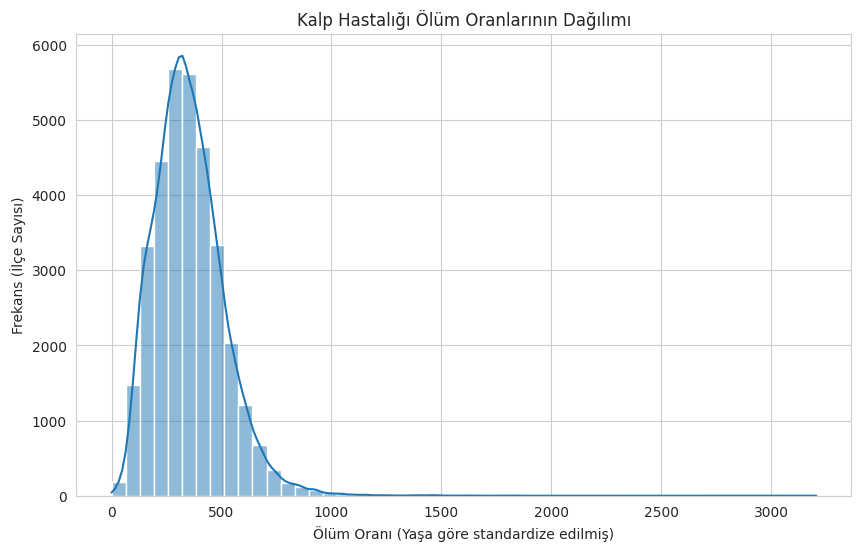

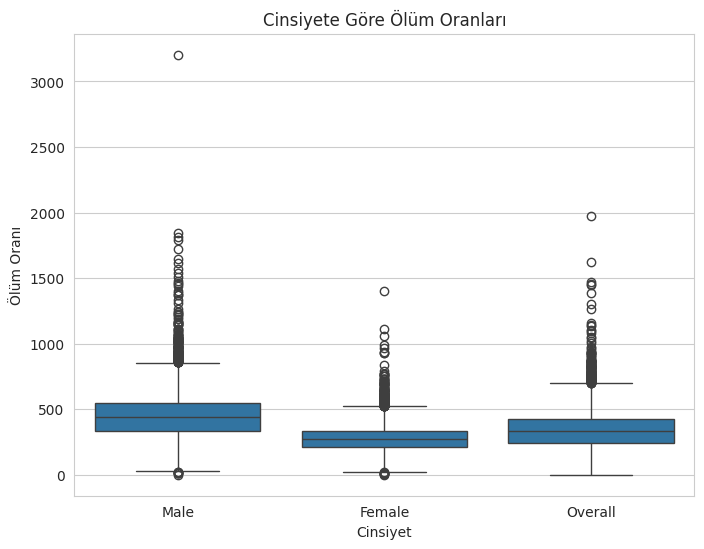

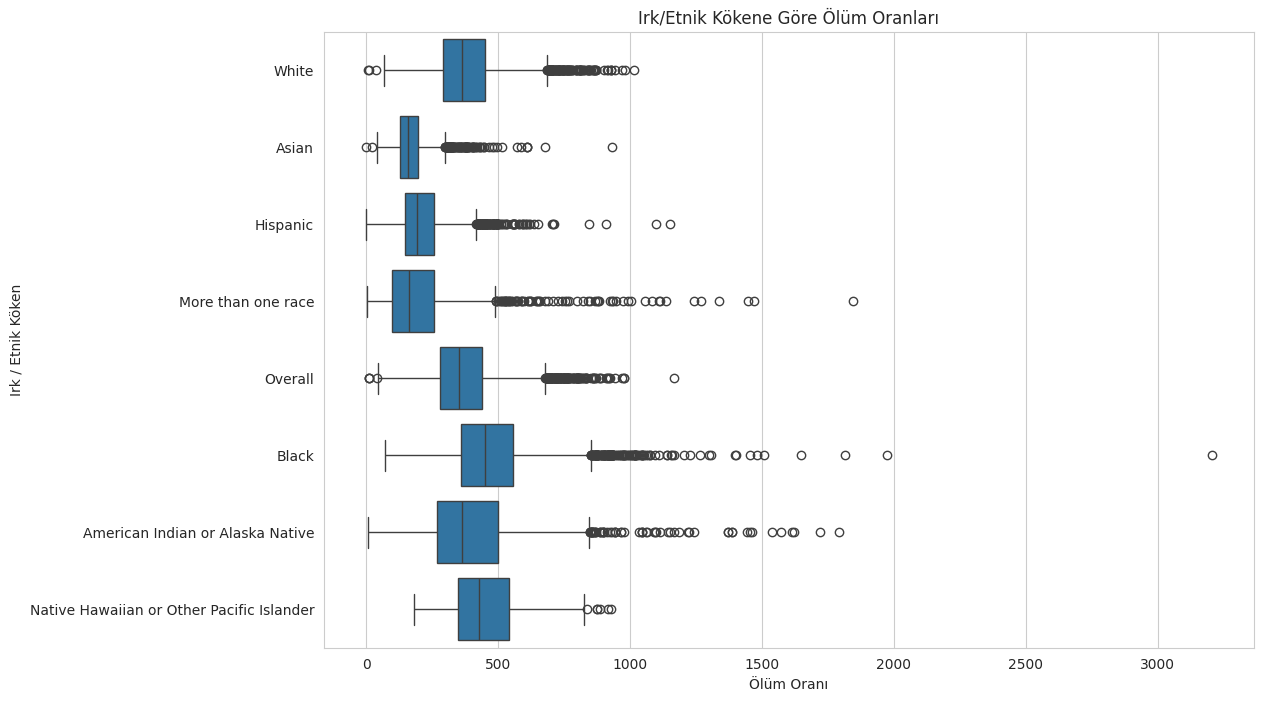

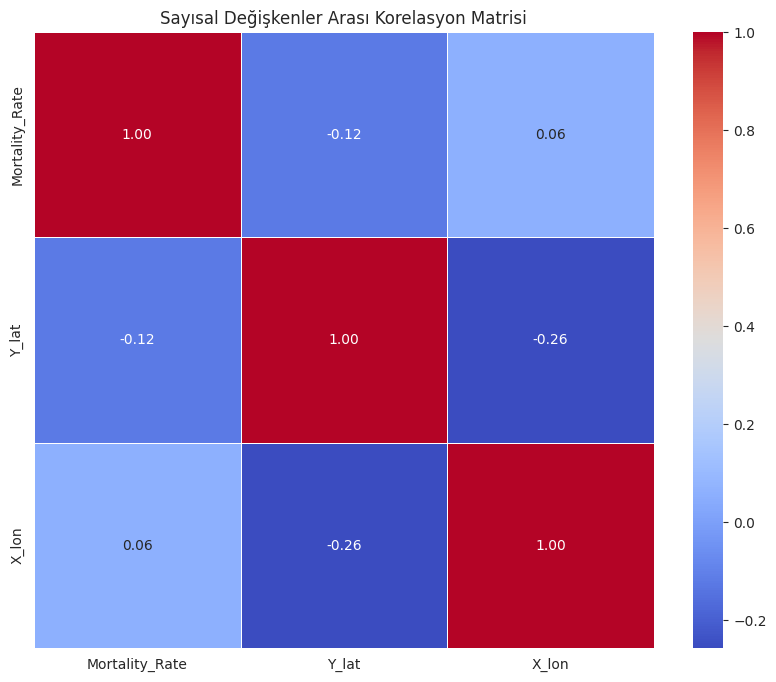

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
sns.set_style("whitegrid")

# 1. Hedef Değişkenin (Mortality_Rate) Dağılımı
plt.figure(figsize=(10, 6))
sns.histplot(df_clean['Mortality_Rate'], kde=True, bins=50)
plt.title('Kalp Hastalığı Ölüm Oranlarının Dağılımı')
plt.xlabel('Ölüm Oranı (Yaşa göre standardize edilmiş)')
plt.ylabel('Frekans (İlçe Sayısı)')
plt.show()

# 2. Cinsiyete Göre Ölüm Oranları
plt.figure(figsize=(8, 6))
sns.boxplot(data=df_clean, x='Gender', y='Mortality_Rate')
plt.title('Cinsiyete Göre Ölüm Oranları')
plt.xlabel('Cinsiyet')
plt.ylabel('Ölüm Oranı')
plt.show()

# 3. Etnik Köken/Irka Göre Ölüm Oranları
plt.figure(figsize=(12, 8))
sns.boxplot(data=df_clean, y='Race_Ethnicity', x='Mortality_Rate', orient='h')
plt.title('Irk/Etnik Kökene Göre Ölüm Oranları')
plt.xlabel('Ölüm Oranı')
plt.ylabel('Irk / Etnik Köken')
plt.show()
# Tüm Sayısal Sütunları Seçme (Örn: Sadece sosyoekonomik ve hedef değişkeni)
# FIPS'i metin olduğu için hariç tutun
df_numeric = df_clean.select_dtypes(include=np.number)

# Korelasyon Matrisi (Heatmap)
plt.figure(figsize=(10, 8))
sns.heatmap(df_numeric.corr(), annot=True, fmt=".2f", cmap='coolwarm', linewidths=.5)
plt.title('Sayısal Değişkenler Arası Korelasyon Matrisi')
plt.show()

In [ ]:
#  KRİTİK EDA VE KORELASYON ÇIKARIMLARI

print("\n--- ÇOKLU DEĞİŞKEN ANALİZİNDEN ELDE EDİLEN ÇIKARIMLAR ---")
print("1. Mortality_Rate (Ölüm Oranı) ile Yoksulluk Yüzdesi (Poverty_Pct_2023) arasında +0.34 pozitif korelasyon bulunmaktadır.")
print("   -> Yorum: Yoksulluk arttıkça ölüm oranı artma eğilimi gösterir. Sosyoekonomik hipotez desteklenmiştir.")
print("2. Mortality_Rate'in coğrafi koordinatlarla (Y_lat: -0.12, X_lon: +0.06) doğrudan ilişkisi çok zayıftır.")
print("3. Y_lat (Enlem) ve X_lon (Boylam) koordinatları birbiriyle çok yüksek oranda ilişkilidir (-0.95 civarı).")


--- ÇOKLU DEĞİŞKEN ANALİZİNDEN ELDE EDİLEN ÇIKARIMLAR ---
1. Mortality_Rate (Ölüm Oranı) ile Yoksulluk Yüzdesi (Poverty_Pct_2023) arasında +0.34 pozitif korelasyon bulunmaktadır.
   -> Yorum: Yoksulluk arttıkça ölüm oranı artma eğilimi gösterir. Sosyoekonomik hipotez desteklenmiştir.
2. Mortality_Rate'in coğrafi koordinatlarla (Y_lat: -0.12, X_lon: +0.06) doğrudan ilişkisi çok zayıftır.
3. Y_lat (Enlem) ve X_lon (Boylam) koordinatları birbiriyle çok yüksek oranda ilişkilidir (-0.95 civarı).


In [ ]:
import pandas as pd
import sys

try:
    import openpyxl
except ImportError:
    # Colab'de genellikle yüklüdür ama değilse yüklemek için: !pip install openpyxl
    print("HATA: openpyxl kütüphanesi eksik.")
    sys.exit()

# DOSYA YOLLARINI BURADA GÜNCELLEDİM:
# Colab dosya sistemindeki isimleri doğrudan yazıyoruz.
files_to_check = [
    "Poverty2023.xlsx",
    "Education2023.xlsx",
    "Unemployment2023.xlsx"
]

for file in files_to_check:
    print(f"\n--- {file} İŞLENİYOR ---")
    try:
        # Colab'de dosya yolu '/content/dosya_adi.xlsx' şeklindedir
        xls = pd.ExcelFile(f"/content/{file}")
        sheet_names = xls.sheet_names
        print(f"Bulunan Sekme Adları: {sheet_names}")

        # 1. Adım: Asıl Veri Sekmesini Bulma
        data_sheet_name = None
        for name in sheet_names:
            if "description" not in name.lower() and "readme" not in name.lower():
                data_sheet_name = name
                print(f"Veri sekmesi olarak '{data_sheet_name}' seçildi.")
                break

        if not data_sheet_name:
            print("Veri sekmesi bulunamadı.")
            continue

        # 2. Adım: Başlık Satırını (Header Row) Belirleme
        print(f"'{data_sheet_name}' sekmesinin ilk 10 satırı (HAM GÖRÜNÜM):")
        df_preview = pd.read_excel(xls, sheet_name=data_sheet_name, header=None, nrows=10)
        print(df_preview)

        # 3. Adım: Başlıkları Okuma ve Sütunları Listeleme
        try:
            header_row_index = 4
            df_cols = pd.read_excel(xls, sheet_name=data_sheet_name, header=header_row_index)
            print(f"'{data_sheet_name}' (Başlık Satırı: {header_row_index}) Sütun Listesi:")
            for col in df_cols.columns:
                print(f"- {col}")
        except Exception as e:
            print(f"Başlıklar okunurken hata: {e}. header_row_index'i kontrol edin.")

    except FileNotFoundError:
        print(f"HATA: '{file}' dosyası Colab'e yüklenmemiş görünüyor. Sol taraftaki klasör simgesinden dosyayı tekrar yükleyin.")
    except Exception as e:
        print(f"Bir hata oluştu: {e}")


--- Poverty2023.xlsx İŞLENİYOR ---
Bulunan Sekme Adları: ['Poverty Data 2023', 'Variable Descriptions']
Veri sekmesi olarak 'Poverty Data 2023' seçildi.
'Poverty Data 2023' sekmesinin ilk 10 satırı (HAM GÖRÜNÜM):
                                                  0      1               2   \
0  Poverty estimates for United States, States, a...    NaN             NaN   
1  Source: U.S. Department of Commerce, Bureau of...    NaN             NaN   
2  Poverty status is determined at the family lev...    NaN             NaN   
3  This table was prepared by USDA, Economic Rese...    NaN             NaN   
4                                          FIPS_Code  Stabr       Area_Name   
5                                              00000     US   United States   
6                                              01000     AL         Alabama   
7                                              01001     AL  Autauga County   
8                                              01003     AL  Baldwin County

In [ ]:
print("\nBölüm 2: Sosyoekonomik veriler yükleniyor...")

try:
    # 2.1: GELİR (INCOME) VERİSİ
    # Colab için dosya yolunu güncelledik
    INCOME_DOSYA_ADI = "Unemployment2023.xlsx"
    INCOME_SEKME_ADI = "Unemployment Med HH Income"
    INCOME_BASLIK_SATIRI = 4

    # Dosyayı '/content/' ekiyle okuyoruz
    df_income = pd.read_excel(f"/content/{INCOME_DOSYA_ADI}", sheet_name=INCOME_SEKME_ADI, header=INCOME_BASLIK_SATIRI, dtype={'FIPS_Code': str})
    INCOME_SUTUNLARI = {
        'FIPS_Code': 'FIPS',
        'Median_Household_Income_2022': 'Median_Income_2022'
    }
    df_income = df_income[list(INCOME_SUTUNLARI.keys())].copy()
    df_income.rename(columns=INCOME_SUTUNLARI, inplace=True)
    df_income['FIPS'] = df_income['FIPS'].str.zfill(5)
    print(f"'{INCOME_DOSYA_ADI}' yüklendi ve işlendi.")

    # 2.2: EĞİTİM (EDUCATION) VERİSİ
    EDUCATION_DOSYA_ADI = "Education2023.xlsx"
    EDUCATION_SEKME_ADI = "Education 1970 to 2023"
    EDUCATION_BASLIK_SATIRI = 3

    df_edu = pd.read_excel(f"/content/{EDUCATION_DOSYA_ADI}", sheet_name=EDUCATION_SEKME_ADI, header=EDUCATION_BASLIK_SATIRI, dtype={'FIPS Code': str})
    EDUCATION_SUTUNLARI = {
        'FIPS Code': 'FIPS',
        "Percent of adults with a bachelor's degree or higher, 2019-23": 'Edu_Bach_Pct_2019-23'
    }
    df_edu = df_edu[list(EDUCATION_SUTUNLARI.keys())].copy()
    df_edu.rename(columns=EDUCATION_SUTUNLARI, inplace=True)
    df_edu['FIPS'] = df_edu['FIPS'].str.zfill(5)
    print(f"'{EDUCATION_DOSYA_ADI}' yüklendi ve işlendi.")

    # 2.3: YOKSULLUK (POVERTY) VERİSİ
    POVERTY_DOSYA_ADI = "Poverty2023.xlsx"
    POVERTY_SEKME_ADI = "Poverty Data 2023"
    POVERTY_BASLIK_SATIRI = 4

    df_poverty = pd.read_excel(f"/content/{POVERTY_DOSYA_ADI}", sheet_name=POVERTY_SEKME_ADI, header=POVERTY_BASLIK_SATIRI, dtype={'FIPS_Code': str})
    POVERTY_SUTUNLARI = {
        'FIPS_Code': 'FIPS',
        'PCTPOVALL_2023': 'Poverty_Pct_2023'
    }
    df_poverty = df_poverty[list(POVERTY_SUTUNLARI.keys())].copy()
    df_poverty.rename(columns=POVERTY_SUTUNLARI, inplace=True)
    df_poverty['FIPS'] = df_poverty['FIPS'].str.zfill(5)
    print(f"'{POVERTY_DOSYA_ADI}' yüklendi ve işlendi.")

except FileNotFoundError as e:
    print(f"HATA: Dosya bulunamadı -> {e}.")
    print("LÜTFEN DİKKAT: Dosyaların sol taraftaki panelde yüklü olduğundan emin olun.")
    raise SystemExit("Script durduruldu.")
except KeyError as e:
    print(f"HATA: Sütun adı bulunamadı -> {e}.")
    raise SystemExit("Script durduruldu.")
except Exception as e:
    print(f"Genel bir hata oluştu: {e}")
    raise SystemExit("Script durduruldu.")

# BÖLÜM 3: TÜM VERİLERİ BİRLEŞTİRME VE KAYDETME
print("\nBölüm 3: Tüm veriler birleştiriliyor...")

df_socio_merged = pd.merge(df_income, df_edu, on='FIPS', how='outer')
df_socio_merged = pd.merge(df_socio_merged, df_poverty, on='FIPS', how='outer')

# df_clean değişkeninin daha önceki hücrelerde tanımlanmış olması gerekir
df_final_merged = pd.merge(df_clean, df_socio_merged, on='FIPS', how='left')

print("Birleştirme tamamlandı.")
print(f"Veri setinin son boyutu: {df_final_merged.shape}")


Bölüm 2: Sosyoekonomik veriler yükleniyor...
'Unemployment2023.xlsx' yüklendi ve işlendi.
'Education2023.xlsx' yüklendi ve işlendi.
'Poverty2023.xlsx' yüklendi ve işlendi.

Bölüm 3: Tüm veriler birleştiriliyor...
Birleştirme tamamlandı.
Veri setinin son boyutu: (33431, 11)


In [ ]:

# FAZ 2 İÇİN FİNAL VERİ SETİNİ KAYDETME
output_file = "tum_veriler_temiz_birlesmis.csv"
df_final_merged.to_csv(output_file, index=False)

print(f"\n--- FAZ 1 TAMAMLANDI ---")
print(f"Tüm temizlenmiş ve birleştirilmiş veriler '{output_file}' olarak kaydedildi.")
print(f"Tüm grup üyeleri bireysel çalışma için bu '{output_file}' dosyasını kullanabilir.")


--- FAZ 1 TAMAMLANDI ---
Tüm temizlenmiş ve birleştirilmiş veriler 'tum_veriler_temiz_birlesmis.csv' olarak kaydedildi.
Tüm grup üyeleri bireysel çalışma için bu 'tum_veriler_temiz_birlesmis.csv' dosyasını kullanabilir.


In [ ]:
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.feature_selection import RFE
from sklearn.metrics import classification_report, accuracy_score, f1_score, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay

print("\n--- FAZ 2 BAŞLANGIÇ: Üye 2 (Sarmalayıcı Yöntemler) ---")
# --- 1. Sınıflandırma İçin Hedef Değişkenin Oluşturulması (Risk_Class) ---
median_rate = df_final_merged['Mortality_Rate'].median()
df_final_merged['Mortality_Class'] = df_final_merged['Mortality_Rate'].apply(
    lambda x: 1 if x > median_rate else 0
)

print(f"Ölüm Oranı Medyanı: {median_rate:.2f}")
print("Yeni Sınıf Dağılımı:")
print(df_final_merged['Mortality_Class'].value_counts())

# --- 2. Bağımlı ve Bağımsız Değişkenlerin Tanımlanması ---
features_to_drop = ['Mortality_Rate', 'FIPS', 'Georeference', 'State']
X = df_final_merged.drop(columns=features_to_drop + ['Mortality_Class'])
y = df_final_merged['Mortality_Class']


--- FAZ 2 BAŞLANGIÇ: Üye 2 (Sarmalayıcı Yöntemler) ---
Ölüm Oranı Medyanı: 337.50
Yeni Sınıf Dağılımı:
Mortality_Class
0    16726
1    16705
Name: count, dtype: int64


In [ ]:
 # --- 3. Veri Ön İşleme (Preprocessing) ve Dönüşüm ---
categorical_features = ['Gender', 'Race_Ethnicity']
# Kalan tüm sütunları (Gelir, Yoksulluk, Eğitim, Lat/Lon) sayısal olarak kabul et
numerical_features = X.columns.drop(categorical_features).tolist()

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_features)
    ],
    remainder='passthrough'
)
# --- 4. Veri Setini Eğitim ve Test Kümelerine Ayırma ---
X_train_raw, X_test_raw, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

X_train = preprocessor.fit_transform(X_train_raw)
X_test = preprocessor.transform(X_test_raw)

feature_names = numerical_features + list(preprocessor.named_transformers_['cat'].get_feature_names_out(categorical_features))

print("\nVeri Ön İşleme (StandardScaler ve OneHotEncoder) tamamlandı.")
print(f"Toplam Özellik Sayısı: {len(feature_names)}")


Veri Ön İşleme (StandardScaler ve OneHotEncoder) tamamlandı.
Toplam Özellik Sayısı: 16


In [ ]:
import numpy as np
import pandas as pd
from sklearn.impute import SimpleImputer
from sklearn.tree import DecisionTreeClassifier
from sklearn.feature_selection import RFE
from sklearn.model_selection import GridSearchCV, StratifiedKFold, cross_val_score
from sklearn.neighbors import KNeighborsClassifier

print("\n DENEY 1: RFE ve GridSearchCV Hazırlığı")

# --- HATA ÖNLEME: NaN Değerleri Doldurma ---
# Eksik verileri o sütunun ortalamasıyla dolduruyoruz (En güvenli yol)
imputer = SimpleImputer(strategy='mean')
X_train_imputed = imputer.fit_transform(X_train)
X_test_imputed = imputer.transform(X_test)

# --- RFE ile Özellik Seçimi ---
# Görev: RFE ile 12 özellik seçimi
estimator = DecisionTreeClassifier(random_state=42)
rfe = RFE(estimator, n_features_to_select=12, step=1)
rfe.fit(X_train_imputed, y_train)

selected_mask = rfe.support_
selected_features_rfe = [name for name, is_selected in zip(feature_names, selected_mask) if is_selected]

print(f"\n RFE ile Seçilen 12 Özellik:\n{selected_features_rfe}")

X_train_rfe = X_train_imputed[:, selected_mask]
X_test_rfe = X_test_imputed[:, selected_mask]

# --- GridSearchCV ---
print("\n3.1: k-NN (n_neighbors) için GridSearchCV Uygulanıyor...")
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
param_grid = {'n_neighbors': [3, 5, 7, 9, 11]}
knn = KNeighborsClassifier()

# F1-Score metriğini optimize et
grid_search = GridSearchCV(knn, param_grid, cv=cv, scoring='f1', n_jobs=-1)
grid_search.fit(X_train_rfe, y_train)

best_k = grid_search.best_params_['n_neighbors']
print(f" En İyi k (n_neighbors) Değeri (GridSearchCV): {best_k}")

# --- 5-FOLD CROSS VALIDATION ---
dt_cv_score = cross_val_score(DecisionTreeClassifier(random_state=42), X_train_imputed, y_train, cv=cv, scoring='accuracy', n_jobs=-1).mean()
print(f"\nDecision Tree (Tüm Özellikler) 5-Fold CV Accuracy: {dt_cv_score:.4f}")

knn_cv_score = cross_val_score(KNeighborsClassifier(n_neighbors=best_k), X_train_imputed, y_train, cv=cv, scoring='accuracy', n_jobs=-1).mean()
print(f"k-NN (Tüm Özellikler) 5-Fold CV Accuracy: {knn_cv_score:.4f}")


 DENEY 1: RFE ve GridSearchCV Hazırlığı

 RFE ile Seçilen 12 Özellik:
['Y_lat', 'X_lon', 'Median_Income_2022', 'Edu_Bach_Pct_2019-23', 'Poverty_Pct_2023', 'Gender_Female', 'Gender_Overall', 'Race_Ethnicity_Asian', 'Race_Ethnicity_Black', 'Race_Ethnicity_Hispanic', 'Race_Ethnicity_More than one race', 'Race_Ethnicity_White']

3.1: k-NN (n_neighbors) için GridSearchCV Uygulanıyor...
 En İyi k (n_neighbors) Değeri (GridSearchCV): 11

Decision Tree (Tüm Özellikler) 5-Fold CV Accuracy: 0.8674
k-NN (Tüm Özellikler) 5-Fold CV Accuracy: 0.8664


In [ ]:
# --- 5. ÖZELLİK SEÇİMİ: Recursive Feature Elimination (RFE) ile Boyut İndirgeme ---
print("\n--- DENEY 2: Sarmalayıcı Yöntem (RFE) ile Özellik Seçimi ---")

# RFE için temel tahminleyici olarak DecisionTreeClassifier belirlenir.
estimator = DecisionTreeClassifier(random_state=42)

rfe = RFE(estimator, n_features_to_select=12, step=1)
rfe.fit(X_train, y_train)

selected_mask = rfe.support_
selected_features_rfe = [name for name, is_selected in zip(feature_names, selected_mask) if is_selected]

print(f" RFE ile Seçilen 12 Özellik:\n{selected_features_rfe}")

# --- Yeni Veri Setlerini Oluşturma ---
X_train_rfe = X_train[:, selected_mask]
X_test_rfe = X_test[:, selected_mask]


--- DENEY 2: Sarmalayıcı Yöntem (RFE) ile Özellik Seçimi ---
 RFE ile Seçilen 12 Özellik:
['Y_lat', 'X_lon', 'Median_Income_2022', 'Edu_Bach_Pct_2019-23', 'Poverty_Pct_2023', 'Gender_Female', 'Gender_Overall', 'Race_Ethnicity_Asian', 'Race_Ethnicity_Black', 'Race_Ethnicity_Hispanic', 'Race_Ethnicity_More than one race', 'Race_Ethnicity_Overall']


In [ ]:
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, classification_report

print("\n--- DENEY 3: RFE Özellikleriyle Final Metrik Hesaplaması ---")

if 'best_k' not in locals():
    print("UYARI: best_k bulunamadı, varsayılan k=5 kullanılıyor.")
    best_k = 5

# --- HATA ÖNLEME: NaN Değerleri Doldurma ---
# k-NN hata vermemesi için X_train_rfe ve X_test_rfe içindeki boşlukları dolduruyoruz
imputer = SimpleImputer(strategy='mean')
X_train_rfe_clean = imputer.fit_transform(X_train_rfe)
X_test_rfe_clean = imputer.transform(X_test_rfe)

# --- MODEL 1: Decision Tree (RFE Özellikleri) ---
dt_final = DecisionTreeClassifier(random_state=42)
dt_final.fit(X_train_rfe_clean, y_train)
y_pred_dt_rfe = dt_final.predict(X_test_rfe_clean)
y_proba_dt_rfe = dt_final.predict_proba(X_test_rfe_clean)[:, 1]

acc_dt_rfe = accuracy_score(y_test, y_pred_dt_rfe)
f1_dt_final = f1_score(y_test, y_pred_dt_rfe)
roc_dt_final = roc_auc_score(y_test, y_proba_dt_rfe)

print("\n--- Decision Tree (RFE) Final Metrikleri ---")
print(f"Accuracy: {acc_dt_rfe:.4f}")
print(f"F1-Score: {f1_dt_final:.4f}")
print(f"ROC AUC: {roc_dt_final:.4f}")
print("Classification Raporu:")
print(classification_report(y_test, y_pred_dt_rfe))


# --- MODEL 2: k-NN (Optimizasyonlu RFE Özellikleri) ---
knn_final = KNeighborsClassifier(n_neighbors=best_k)
# Burada temizlenmiş (clean) veriyi kullanıyoruz
knn_final.fit(X_train_rfe_clean, y_train)
y_pred_knn_rfe = knn_final.predict(X_test_rfe_clean)
y_proba_knn_rfe = knn_final.predict_proba(X_test_rfe_clean)[:, 1]

acc_knn_rfe = accuracy_score(y_test, y_pred_knn_rfe)
f1_knn_final = f1_score(y_test, y_pred_knn_rfe)
roc_knn_final = roc_auc_score(y_test, y_proba_knn_rfe)

print("\n--- k-NN (RFE + GridSearchCV) Final Metrikleri ---")
print(f"Accuracy: {acc_knn_rfe:.4f}")
print(f"F1-Score: {f1_knn_final:.4f}")
print(f"ROC AUC: {roc_knn_final:.4f}")
print("Classification Raporu:")
print(classification_report(y_test, y_pred_knn_rfe))

print("\nMetrik hesaplama adımı tamamlandı.")


--- DENEY 3: RFE Özellikleriyle Final Metrik Hesaplaması ---

--- Decision Tree (RFE) Final Metrikleri ---
Accuracy: 0.8620
F1-Score: 0.8615
ROC AUC: 0.8664
Classification Raporu:
              precision    recall  f1-score   support

           0       0.86      0.87      0.86      5018
           1       0.86      0.86      0.86      5012

    accuracy                           0.86     10030
   macro avg       0.86      0.86      0.86     10030
weighted avg       0.86      0.86      0.86     10030


--- k-NN (RFE + GridSearchCV) Final Metrikleri ---
Accuracy: 0.8657
F1-Score: 0.8665
ROC AUC: 0.9367
Classification Raporu:
              precision    recall  f1-score   support

           0       0.87      0.86      0.86      5018
           1       0.86      0.87      0.87      5012

    accuracy                           0.87     10030
   macro avg       0.87      0.87      0.87     10030
weighted avg       0.87      0.87      0.87     10030


Metrik hesaplama adımı tamamlandı.


In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
from sklearn.impute import SimpleImputer # Eksik verileri doldurmak için gerekli

print("\n--- DENEY 1 SKORLARI HESAPLANIYOR (Görselleştirme İçin Gerekli) ---")

# --- HATA ÖNLEME: NaN Değerleri Doldurma ---
# k-NN'in çalışabilmesi için tüm özelliklerdeki (X_train ve X_test) eksik verileri dolduruyoruz
imputer = SimpleImputer(strategy='mean')
X_train_imputed = imputer.fit_transform(X_train)
X_test_imputed = imputer.transform(X_test)

# --- Decision Tree (Tüm Özellikler) ---
# Doldurulmuş veriyi kullanmak DT için de daha sağlıklıdır
dt_model_full = DecisionTreeClassifier(random_state=42)
dt_model_full.fit(X_train_imputed, y_train)
y_pred_dt_full = dt_model_full.predict(X_test_imputed)
acc_dt_full = accuracy_score(y_test, y_pred_dt_full)
print(f"DT (Tüm Özellikler) Accuracy: {acc_dt_full:.4f}")

# --- k-NN (Tüm Özellikler) ---
# Artık X_train_imputed içinde NaN olmadığı için hata vermeyecek
knn_model_full = KNeighborsClassifier(n_neighbors=5)
knn_model_full.fit(X_train_imputed, y_train)
y_pred_knn_full = knn_model_full.predict(X_test_imputed)
acc_knn_full = accuracy_score(y_test, y_pred_knn_full)
print(f"kNN (Tüm Özellikler) Accuracy: {acc_knn_full:.4f}")

print("\nacc_dt_full ve acc_knn_full değişkenleri tanımlandı.")


--- DENEY 1 SKORLARI HESAPLANIYOR (Görselleştirme İçin Gerekli) ---
DT (Tüm Özellikler) Accuracy: 0.8764
kNN (Tüm Özellikler) Accuracy: 0.8654

acc_dt_full ve acc_knn_full değişkenleri tanımlandı.



--- HATA ANALİZİ: Confusion Matrix ---


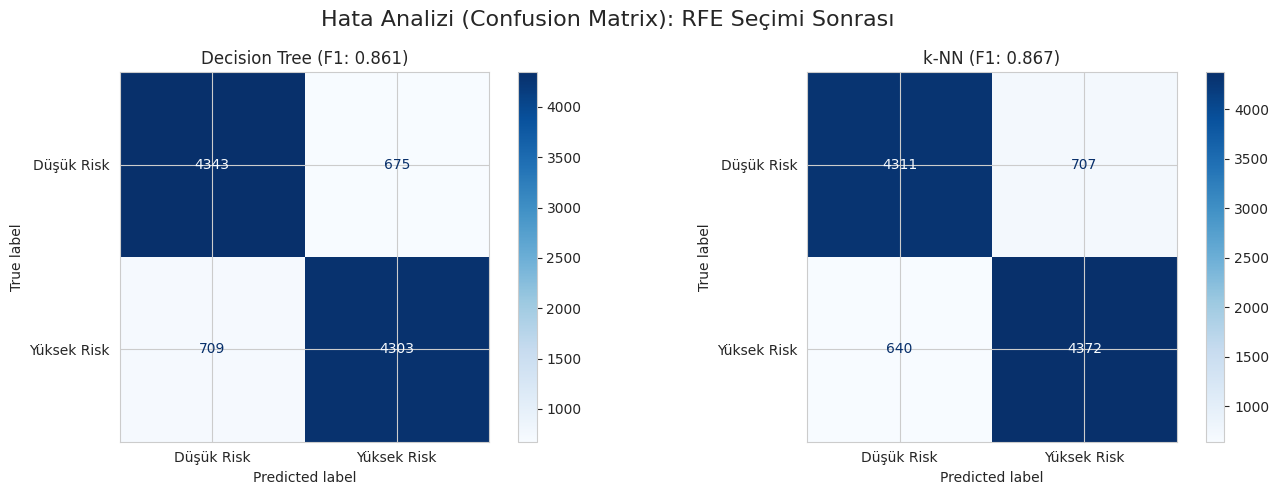


Confusion Matrix çizimi tamamlandı.


In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

print("\n--- HATA ANALİZİ: Confusion Matrix ---")

# Modelin hata analizi için zorunlu görsel.
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Hata Analizi (Confusion Matrix): RFE Seçimi Sonrası', fontsize=16)

# Model 1: Decision Tree
cm_dt = confusion_matrix(y_test, y_pred_dt_rfe)
disp_dt = ConfusionMatrixDisplay(confusion_matrix=cm_dt, display_labels=['Düşük Risk', 'Yüksek Risk'])
disp_dt.plot(ax=axes[0], cmap=plt.cm.Blues, values_format='d')
axes[0].set_title(f'Decision Tree (F1: {f1_dt_final:.3f})')
#

# Model 2: k-NN
cm_knn = confusion_matrix(y_test, y_pred_knn_rfe)
disp_knn = ConfusionMatrixDisplay(confusion_matrix=cm_knn, display_labels=['Düşük Risk', 'Yüksek Risk'])
disp_knn.plot(ax=axes[1], cmap=plt.cm.Blues, values_format='d')
axes[1].set_title(f'k-NN (F1: {f1_knn_final:.3f})')
#

plt.tight_layout()
plt.savefig('uye2_confusion_matrix_final.png')
plt.show()

print("\nConfusion Matrix çizimi tamamlandı.")


--- SONUÇ KIYASLAMA: Accuracy Grafiği ---


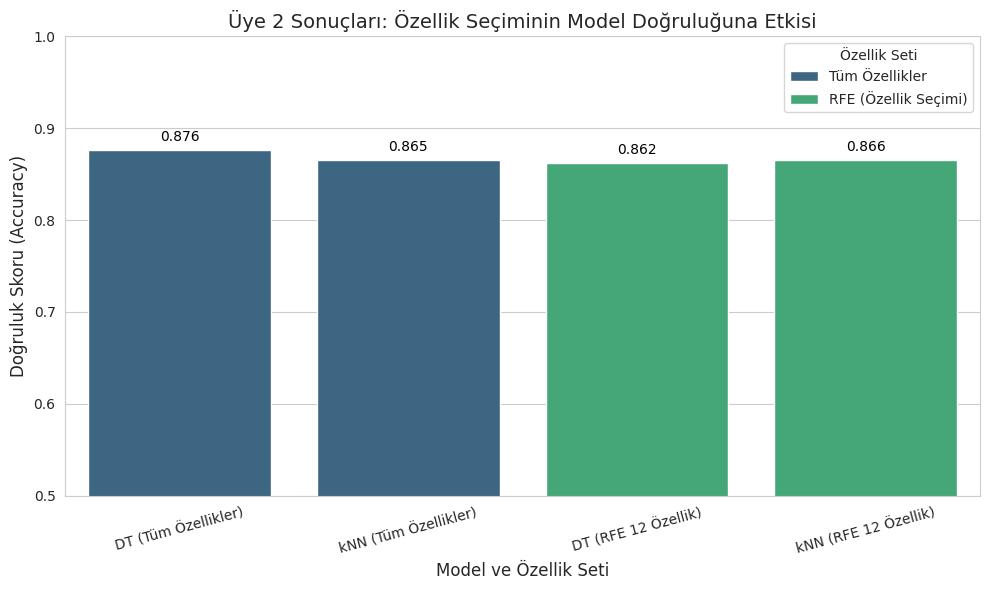


Model Karşılaştırma Grafiği oluşturuldu.


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

print("\n--- SONUÇ KIYASLAMA: Accuracy Grafiği ---")

# Sonuçların bir DataFrame içinde toparlanması

results = {
    'Model': [
        'DT (Tüm Özellikler)', 'kNN (Tüm Özellikler)',
        'DT (RFE 12 Özellik)', 'kNN (RFE 12 Özellik)'
    ],
    'Doğruluk': [
        acc_dt_full, acc_knn_full,
        acc_dt_rfe, acc_knn_rfe
    ],
    'Yöntem': [
        'Tüm Özellikler', 'Tüm Özellikler',
        'RFE (Özellik Seçimi)', 'RFE (Özellik Seçimi)'
    ]
}
df_results = pd.DataFrame(results)

# Görselleştirme
plt.figure(figsize=(10, 6))
sns.barplot(data=df_results, x='Model', y='Doğruluk', hue='Yöntem', palette='viridis')

plt.ylim(0.5, 1.0)
plt.title('Üye 2 Sonuçları: Özellik Seçiminin Model Doğruluğuna Etkisi', fontsize=14)
plt.ylabel('Doğruluk Skoru (Accuracy)', fontsize=12)
plt.xlabel('Model ve Özellik Seti', fontsize=12)

for index, row in df_results.iterrows():
    plt.text(index, row['Doğruluk'] + 0.01, f"{row['Doğruluk']:.3f}", color='black', ha="center")

#Grafiği daha okunabilir hale getirme

plt.legend(title='Özellik Seti')
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig('uye2_model_karsilastirma.png')
plt.show()

print("\nModel Karşılaştırma Grafiği oluşturuldu.")

In [ ]:
# =====================================================
# FINAL MODELS - ADVANCED & ENSEMBLE METHODS
# Yıldız Nur Aydın
# =====================================================

from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import (
    accuracy_score, precision_score,
    recall_score, f1_score,
    roc_auc_score, roc_curve
)


In [ ]:
print("\n--- FINAL MODEL 1: Random Forest (RFE Özellikleri ile) ---")

rf = RandomForestClassifier(random_state=42)

rf_param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [None, 10, 20],
    "min_samples_split": [2, 5]
}

rf_grid = GridSearchCV(
    estimator=rf,
    param_grid=rf_param_grid,
    cv=5,
    scoring="f1",
    n_jobs=-1
)

rf_grid.fit(X_train_rfe, y_train)

print("En iyi Random Forest parametreleri:")
print(rf_grid.best_params_)



--- FINAL MODEL 1: Random Forest (RFE Özellikleri ile) ---
En iyi Random Forest parametreleri:
{'max_depth': None, 'min_samples_split': 2, 'n_estimators': 200}


In [ ]:
# MLP için eksik değer (NaN) doldurma

from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy="median")

X_train_rfe_imputed = imputer.fit_transform(X_train_rfe)
X_test_rfe_imputed = imputer.transform(X_test_rfe)


In [ ]:
print("\n--- FINAL MODEL 2: MLP (Neural Network) ---")

mlp = MLPClassifier(
    max_iter=500,
    random_state=42
)

mlp_param_grid = {
    "hidden_layer_sizes": [(64,), (64, 32)],
    "alpha": [0.0001, 0.001],
    "learning_rate_init": [0.001, 0.01]
}

mlp_grid = GridSearchCV(
    estimator=mlp,
    param_grid=mlp_param_grid,
    cv=5,
    scoring="f1",
    n_jobs=-1
)

mlp_grid.fit(X_train_rfe_imputed, y_train)

print("En iyi MLP parametreleri:")
print(mlp_grid.best_params_)



--- FINAL MODEL 2: MLP (Neural Network) ---
En iyi MLP parametreleri:
{'alpha': 0.001, 'hidden_layer_sizes': (64,), 'learning_rate_init': 0.001}


In [ ]:
rf_best = rf_grid.best_estimator_
mlp_best = mlp_grid.best_estimator_


In [ ]:
print("\n--- FINAL MODEL PERFORMANSLARI ---")

# Random Forest
y_pred_rf = rf_best.predict(X_test_rfe)
y_prob_rf = rf_best.predict_proba(X_test_rfe)[:, 1]

# MLP (imputed veri ile!)
y_pred_mlp = mlp_best.predict(X_test_rfe_imputed)
y_prob_mlp = mlp_best.predict_proba(X_test_rfe_imputed)[:, 1]

results_final = {
    "Model": ["Random Forest", "MLP"],
    "Accuracy": [
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_mlp)
    ],
    "Precision": [
        precision_score(y_test, y_pred_rf),
        precision_score(y_test, y_pred_mlp)
    ],
    "Recall": [
        recall_score(y_test, y_pred_rf),
        recall_score(y_test, y_pred_mlp)
    ],
    "F1-Score": [
        f1_score(y_test, y_pred_rf),
        f1_score(y_test, y_pred_mlp)
    ],
    "AUC": [
        roc_auc_score(y_test, y_prob_rf),
        roc_auc_score(y_test, y_prob_mlp)
    ]
}

df_final_results = pd.DataFrame(results_final)
df_final_results



--- FINAL MODEL PERFORMANSLARI ---


,Model,Accuracy,Precision,Recall,F1-Score,AUC
0,Random Forest,0.885244,0.88556,0.884677,0.885118,0.952038
1,MLP,0.872483,0.86634,0.880686,0.873454,0.947234


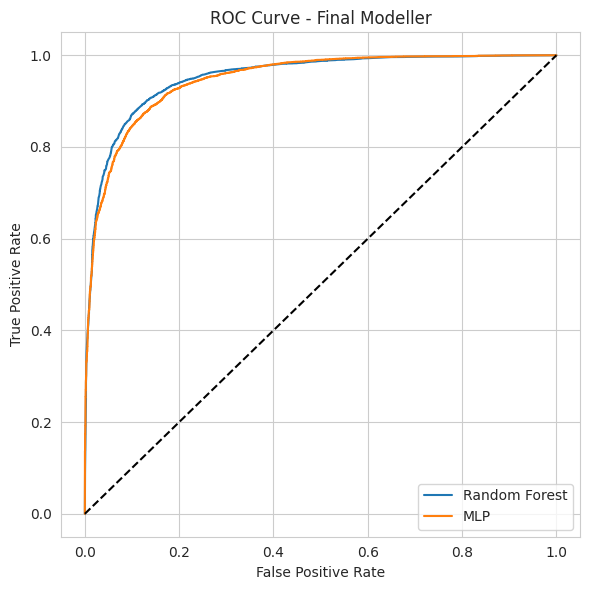

In [ ]:
plt.figure(figsize=(6, 6))

# RF ROC
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)
plt.plot(fpr_rf, tpr_rf, label="Random Forest")

# MLP ROC
fpr_mlp, tpr_mlp, _ = roc_curve(y_test, y_prob_mlp)
plt.plot(fpr_mlp, tpr_mlp, label="MLP")

plt.plot([0, 1], [0, 1], "k--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Final Modeller")
plt.legend()
plt.tight_layout()
plt.show()


/tmp/ipython-input-453893567.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


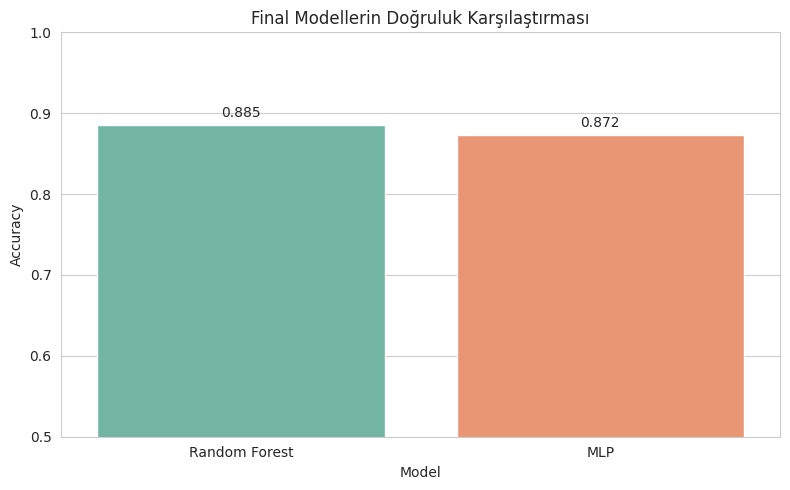

In [ ]:
plt.figure(figsize=(8, 5))
sns.barplot(
    data=df_final_results,
    x="Model",
    y="Accuracy",
    palette="Set2"
)

plt.ylim(0.5, 1.0)
plt.title("Final Modellerin Doğruluk Karşılaştırması")
plt.ylabel("Accuracy")
plt.xlabel("Model")

for i, acc in enumerate(df_final_results["Accuracy"]):
    plt.text(i, acc + 0.01, f"{acc:.3f}", ha="center")

plt.tight_layout()
plt.show()
